## **ASSIGNMENT 2:** Image Interpolation and Intensity Transformations

### **1. Importing necessary libraries**

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

### **2. Loading the image**

In [2]:
try: 
    path = r"..\data\example_image.jpg" # <- input your own path here
    img = Image.open(path)
    img.load()
    print("Image loaded sucessfully!")
except FileNotFoundError:
    print("Error: Image not found.")
except OSError:
    print("Error: File is not a valid image.")

Image loaded sucessfully!


### **3. Checking if the image is an 8-bit grayscale image**

In [3]:
if img.mode == "L":
    print("Image is already 8-bit grayscale.")
else:
    print(f"Image mode is {img.mode}. Converting it to 8-bit grayscale ...")
    img = img.convert("L")

Image mode is RGB. Converting it to 8-bit grayscale ...


### **4. Convert to Numpy array**

In [4]:
img_array = np.array(img, dtype=np.float32)

---

### **5. TASK:** Intensity Transformation

In [5]:
# 1. Negative transformation
def negative_transform(image):
    # s = (L−1) − r
    L = 256 
    output = np.zeros_like(image)
    for i in range(image.shape[0]):
        for j in range(image.shape[1]):
            output[i, j] = L - 1 - image[i, j]
    return output


# 2. Logarithmic transformation
def log_transform(image, c=1):
    # s = c * log(1 + r)
    output = np.zeros_like(image)
    for i in range(image.shape[0]):
        for j in range(image.shape[1]):
            output[i, j] = c * np.log(1 + image[i, j])
    output = output * (255 / np.max(output))
    return output


# 3. Gamma transformation
def gamma_transform(image, gamma=1, c=1):
    # s = c * r^gamma
    output = np.zeros_like(image)
    for i in range(image.shape[0]):
        for j in range(image.shape[1]):
            output[i, j] = c * (image[i, j] ** gamma)
    output = output * (255 / np.max(output))
    return output

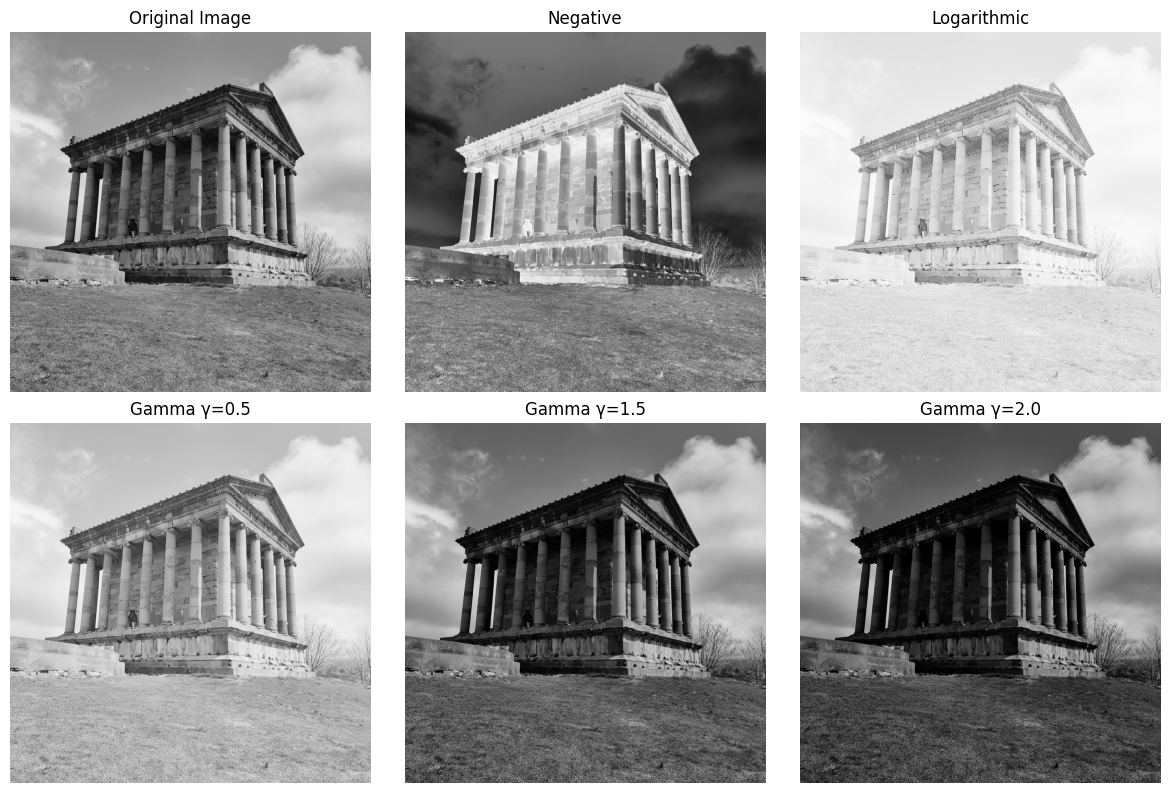

In [6]:
# applying transformations
neg_img = negative_transform(img_array)
log_img = log_transform(img_array, c=1)
gamma_values = [0.5, 1.5, 2.0]
gamma_imgs = [gamma_transform(img_array, g, 1) for g in gamma_values]

# displaying results
plt.figure(figsize=(12, 8))

plt.subplot(2, 3, 1)
plt.imshow(img_array, cmap='gray')
plt.title("Original Image")
plt.axis('off')

plt.subplot(2, 3, 2)
plt.imshow(neg_img, cmap='gray')
plt.title("Negative")
plt.axis('off')

plt.subplot(2, 3, 3)
plt.imshow(log_img, cmap='gray')
plt.title("Logarithmic")
plt.axis('off')

for i, gamma_img in enumerate(gamma_imgs):
    plt.subplot(2, 3, i + 4)
    plt.imshow(gamma_img, cmap='gray')
    plt.title(f"Gamma γ={gamma_values[i]}")
    plt.axis('off')

plt.tight_layout()
plt.show()